# 向量矩阵与线性变换

学习目标：把二维点的缩放、旋转与复合写成矩阵运算，理解线性组合、形状、转置与逆的含义。

前置知识：平面坐标、有限求和、基本三角函数；Python 变量、数组索引、循环与模块导入。

运行环境：Python 3.12、NumPy 2.5、Matplotlib 3.11；本章使用实数和有限维数组。

环境准备：[环境配置与运行](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 从坐标到数组

### 1.1 标量、向量与矩阵

平面点的两个坐标可以写成列向量 $x=\begin{bmatrix}2\\1\end{bmatrix}$。单个实数称为标量；把几个数按顺序放在一起，可以表示一个向量。

本章默认向量竖写。$x\in\mathbb{R}^n$ 表示有 $n$ 个实数分量；$A\in\mathbb{R}^{m\times n}$ 表示有 $m$ 行、$n$ 列的实矩阵，其中 $m,n$ 为正整数。元素 $A_{ij}$ 位于第 $i$ 行、第 $j$ 列，数学索引从 1 开始，数组索引从 0 开始。

| 原文名称 | 中文名称／含义 | 本章表示 |
| --- | --- | --- |
| scalar | 标量，一个数 | Python 数值或零维数组 |
| vector | 向量，有序分量 | 一维数组，或显式的单列二维数组 |
| matrix | 矩阵，按行列排列的数 | 二维数组 |
| multidimensional array | 多维数组，用多个轴组织数据 | NumPy 的 ndarray |

下面先查看 shape（各轴长度）和 ndim（轴数）。两个坐标组成的向量属于二维坐标空间，但保存它的一维数组只有一个轴；这两种“维”要分清。

In [1]:
import numpy as np

scalar = np.array(3.0)
point = np.array([2.0, 1.0])
matrix = np.array([[2.0, 0.0], [0.0, 3.0]])

print(scalar.shape, scalar.ndim)  # 预期：() 0；零维数组没有轴。
print(point.shape, point.ndim)  # 预期：(2,) 1；含两个坐标。
print(matrix.shape, matrix.ndim)  # 预期：(2, 2) 2；两行两列。
print(matrix[1, 1])  # 预期：3.0，对应数学记号 A_22。

() 0
(2,) 1
(2, 2) 2
3.0


### 1.2 列向量不等于一维数组

point 的形状是 (2,)，没有“行轴”和“列轴”。用 reshape(2, 1) 显式构造两行一列；reshape(1, 2) 则是一行两列。下面的点、列、行保存相同的两个数，但参与运算时的形状不同。

把多个矩阵叠放，还可以得到三个轴的数组。这里约定第一个轴选择样本，后两个轴才是每个矩阵的行和列；形状本身不会说明各轴的业务含义。

In [2]:
column = point.reshape(2, 1)
row = point.reshape(1, 2)
batch = np.array([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])

print(column, column.shape)  # 两行一列，形状 (2, 1)。
print(row, row.shape)  # 一行两列，形状 (1, 2)。
print(batch.shape, batch.ndim)  # 预期：(2, 2, 2) 3。
print(batch[1])  # 第二个矩阵为 [[5, 6], [7, 8]]。

[[2.]
 [1.]] (2, 1)
[[2. 1.]] (1, 2)
(2, 2, 2) 3
[[5 6]
 [7 8]]


## 2 线性组合

先把 $u=\begin{bmatrix}1\\2\end{bmatrix}$ 放大两倍，再减去 $v=\begin{bmatrix}3\\1\end{bmatrix}$，得到

$$2u-v=\begin{bmatrix}2\cdot1-3\\2\cdot2-1\end{bmatrix}=\begin{bmatrix}-1\\3\end{bmatrix}.$$

一般地，同属 $\mathbb{R}^n$ 的向量 $v_1,\ldots,v_k$ 及实数系数 $c_1,\ldots,c_k$ 构成线性组合 $\sum_{j=1}^{k}c_jv_j$，其中 $k$ 为正整数。先按系数缩放，再对应分量相加；相加的向量必须属于同一个坐标空间。

几何上，正系数保留方向，负系数反转方向，零系数得到零向量；向量相加可按箭头首尾相接来理解。

In [3]:
u = np.array([1.0, 2.0])
v = np.array([3.0, 1.0])

print(2 * u - v)  # 预期：[-1.  3.]，逐分量核对手算。
print(u + v)  # 预期：[4. 3.]
print(-u, 0 * u)  # 反向向量 [-1. -2.] 与零向量 [0. 0.]。

[-1.  3.]
[4. 3.]
[-1. -2.] [0. 0.]


## 3 矩阵乘法与形状

### 3.1 矩阵乘向量

设 $A=\begin{bmatrix}2&1\\0&3\end{bmatrix}$，输入 $x=\begin{bmatrix}2\\1\end{bmatrix}$。按行计算：

$$Ax=\begin{bmatrix}2\cdot2+1\cdot1\\0\cdot2+3\cdot1\end{bmatrix}=\begin{bmatrix}5\\3\end{bmatrix}.$$

也可以按列理解：$Ax=2\begin{bmatrix}2\\0\end{bmatrix}+1\begin{bmatrix}1\\3\end{bmatrix}$。输入的分量是系数，输出是矩阵各列的线性组合。

对于 $A\in\mathbb{R}^{m\times n}$ 和 $x\in\mathbb{R}^n$，输出 $y=Ax\in\mathbb{R}^m$，第 $i$ 个分量为 $y_i=\sum_{j=1}^{n}A_{ij}x_j$，其中 $i=1,\ldots,m$。NumPy 用 @ 进行矩阵乘法；右侧一维数组会按向量参与计算，结果仍是一维数组。

In [4]:
a = np.array([[2.0, 1.0], [0.0, 3.0]])
x = np.array([2.0, 1.0])

print(a @ x)  # 预期：[5. 3.]
print(x[0] * a[:, 0] + x[1] * a[:, 1])  # 同样得到 [5. 3.]。
print((a @ x).shape)  # 预期：(2,)
print((a @ x.reshape(2, 1)).shape)  # 显式列向量得到 (2, 1)。

[5. 3.]
[5. 3.]
(2,)
(2, 1)


### 3.2 矩阵乘矩阵

若 $A\in\mathbb{R}^{m\times n}$、$B\in\mathbb{R}^{n\times p}$，则 $C=AB\in\mathbb{R}^{m\times p}$，其中 $p$ 为正整数。相接的两个维度必须相等：

$$C_{ij}=\sum_{k=1}^{n}A_{ik}B_{kj},\qquad i=1,\ldots,m,\quad j=1,\ldots,p.$$

每个元素取左矩阵的一行与右矩阵的一列，对应相乘再求和。例如：

$$\begin{bmatrix}1&2&0\\-1&1&3\end{bmatrix}\begin{bmatrix}2&1\\0&4\\1&-1\end{bmatrix}
=\begin{bmatrix}1\cdot2+2\cdot0+0\cdot1&1\cdot1+2\cdot4+0\cdot(-1)\\-1\cdot2+1\cdot0+3\cdot1&-1\cdot1+1\cdot4+3\cdot(-1)\end{bmatrix}
=\begin{bmatrix}2&9\\1&0\end{bmatrix}.$$

先预测形状再计算。即使 AB 和 BA 都有定义，形状也可能不同，更不能直接调换顺序。

In [5]:
left = np.array([[1, 2, 0], [-1, 1, 3]])
right = np.array([[2, 1], [0, 4], [1, -1]])
product = left @ right

print(product)  # 预期：[[2, 9], [1, 0]]。
print(left.shape, right.shape, product.shape)  # (2, 3) (3, 2) (2, 2)
print((right @ left).shape)  # 预期：(3, 3)，顺序改变了输出空间。

[[2 9]
 [1 0]]
(2, 3) (3, 2) (2, 2)
(3, 3)


### 3.3 逐元素运算不是矩阵乘法

两个同形状数组使用 * 时，对应元素直接相乘；使用 @ 时，按矩阵乘法求和。标量与数组相乘也使用 *。本章的矩阵加减只讨论同形状情形。

NumPy 还支持广播（broadcasting）：从末轴对齐，轴长相等或其中一个为 1 时，可以扩展较短的轴。因此，“代码能运行”不保证形状符合数学意图。特别是 (2,) 与 (2, 1) 相加会形成 (2, 2)，并非两个列向量相加。

In [6]:
first = np.array([[1, 2], [3, 4]])
second = np.array([[2, 0], [1, 3]])

print(first * second)  # 预期：[[2, 0], [3, 12]]。
print(first @ second)  # 预期：[[4, 6], [10, 12]]。
print(first + second)  # 预期：[[3, 2], [4, 7]]。
print((point + column).shape)  # 预期：(2, 2)，意外发生了广播。
print((column + column).shape)  # 预期：(2, 1)，保留列向量布局。

[[ 2  0]
 [ 3 12]]


[[ 4  6]
 [10 12]]
[[3 2]
 [4 7]]
(2, 2)
(2, 1)


## 4 转置、单位矩阵与逆

### 4.1 转置交换行和列

对 $A\in\mathbb{R}^{m\times n}$，转置 $A^{\mathsf T}\in\mathbb{R}^{n\times m}$ 满足 $(A^{\mathsf T})_{ji}=A_{ij}$。二维数组的 .T 对应这个操作；一维数组只有一个轴，.T 不会把它变成列向量。

若 AB 有定义，则 $(AB)^{\mathsf T}=B^{\mathsf T}A^{\mathsf T}$，顺序也反过来。两边的第 $(j,i)$ 项分别为 $\sum_k A_{ik}B_{kj}$ 和 $\sum_k B_{kj}A_{ik}$；每一项是实数乘积，所以相等。

In [7]:
# 使用第 3.2 节的 left、right；转置后形状依次为 (3, 2)、(2, 3)。
print(left.T)  # 预期为 3×2 矩阵，三行依次是 [1, -1]、[2, 1]、[0, 3]。
print(point.T.shape, column.T.shape)  # 预期：(2,) (1, 2)。
print((left @ right).T)  # 预期为 [[2, 1], [9, 0]]，与下一行的逆序转置乘积相同。
print(right.T @ left.T)  # 两次输出均为 [[2, 1], [9, 0]]。

[[ 1 -1]
 [ 2  1]
 [ 0  3]]
(2,) (1, 2)
[[2 1]
 [9 0]]
[[2 1]
 [9 0]]


### 4.2 单位矩阵保持输入

$I_n$ 是 $n\times n$ 单位矩阵，主对角线为 1，其余元素为 0。它满足 $I_nx=x$。对于 $A\in\mathbb{R}^{m\times n}$，左右两侧所需大小不同：$I_mA=A=AI_n$。

np.eye(n) 创建这样的二维数组。下面沿用形状为 (2, 3) 的 left，分别检查左乘和右乘。

In [8]:
identity_2 = np.eye(2)
identity_3 = np.eye(3)

print(identity_2 @ point)  # 预期：[2. 1.]，点没有改变。
print(identity_2 @ left)  # 两行三列，数值与 left 相同。
print(left @ identity_3)  # 同样保持 left；右侧需要三阶单位矩阵。

[2. 1.]
[[ 1.  2.  0.]
 [-1.  1.  3.]]
[[ 1.  2.  0.]
 [-1.  1.  3.]]


### 4.3 逆矩阵撤销变换

对于方阵 $A\in\mathbb{R}^{n\times n}$，若存在同形状矩阵 $A^{-1}$，满足 $A^{-1}A=AA^{-1}=I_n$，则 A 可逆，$A^{-1}$ 称为逆矩阵。不是每个方阵都可逆；非方阵不使用本节的双侧逆定义。

例如 $S=\begin{bmatrix}2&0\\0&3\end{bmatrix}$ 分别把两个坐标放大 2 倍和 3 倍。把各坐标再缩小到原来的 $1/2$ 和 $1/3$，得到 $S^{-1}=\begin{bmatrix}1/2&0\\0&1/3\end{bmatrix}$。乘回去的两个对角元素都是 1，其余元素是 0。

np.linalg.inv 计算逆；1 / 数组只是逐元素倒数。浮点检查用 np.allclose，并先核对形状。本例数值约为 1～10，选绝对容差 $10^{-12}$、相对容差 0；这只是本例的误差尺度，不能直接套给任意矩阵。

In [9]:
scale = np.array([[2.0, 0.0], [0.0, 3.0]])
scale_inverse = np.linalg.inv(scale)

print(scale_inverse)  # 对角线约为 0.5、0.33333333，其余为 0。
print(scale_inverse @ (scale @ point))  # 预期：恢复 [2. 1.]。
print(np.allclose(scale_inverse @ scale, np.eye(2), rtol=0, atol=1e-12))  # 预期 True，左乘逆矩阵得到单位阵。
print(np.allclose(scale @ scale_inverse, np.eye(2), rtol=0, atol=1e-12))  # 预期 True，右乘逆矩阵也得到单位阵。
# 两个方向均应为 True；同时核对逆的定义。

[[0.5        0.        ]
 [0.         0.33333333]]
[2. 1.]
True
True


### 4.4 丢失坐标后无法恢复

$P=\begin{bmatrix}1&0\\0&0\end{bmatrix}$ 把第二个坐标压到 0。不同输入 $\begin{bmatrix}2\\1\end{bmatrix}$ 和 $\begin{bmatrix}2\\7\end{bmatrix}$ 都得到 $\begin{bmatrix}2\\0\end{bmatrix}$，所以输出不能唯一确定原输入；这个方阵不可逆。

库检测到不可逆矩阵时会抛出 LinAlgError。数值接近不可逆的矩阵则可能没有异常，却仍产生很大的误差；不能把“inv 没报错”视为精度保证。

In [10]:
collapse = np.array([[1.0, 0.0], [0.0, 0.0]])
print(collapse @ np.array([2.0, 1.0]))  # 预期：[2. 0.]
print(collapse @ np.array([2.0, 7.0]))  # 同样为 [2. 0.]。

[2. 0.]
[2. 0.]


In [11]:
# 预期 LinAlgError：奇异矩阵不能求逆。
np.linalg.inv(collapse)

LinAlgError: Singular matrix

## 5 从矩阵看线性变换

### 5.1 线性的两个条件

变换 $T:\mathbb{R}^n\to\mathbb{R}^m$ 为每个输入向量指定一个输出向量。线性变换要求，对任意 $u,v\in\mathbb{R}^n$ 和任意实数 $c$，都有

$$T(u+v)=T(u)+T(v),\qquad T(cu)=cT(u).$$

矩阵变换 $T(x)=Ax$ 满足这两条规则。反过来，在本章的实坐标空间中，每个线性变换都可以写成矩阵乘法。取 $c=0$ 可知线性变换必须保持原点。

把每个点加上固定非零向量 $b$ 的平移 $F(x)=x+b$ 不保持原点，因此不属于线性变换。下面的数值等式用于核对一个例子，不能替代“任意输入都成立”的证明。

In [12]:
transform = np.array([[2.0, 1.0], [0.0, 1.0]])
u = np.array([1.0, 2.0])
v = np.array([-1.0, 1.0])

print(transform @ (u + v), transform @ u + transform @ v)  # 两种计算都得到 [3, 3]。
# 预期：两者均为 [3. 3.]。
print(transform @ (2 * u), 2 * (transform @ u))  # 均为 [8. 4.]。
offset = np.array([1.0, 0.0])
print(np.zeros(2) + offset)  # 预期：[1. 0.]，平移不保持原点。

[3. 3.] [3. 3.]
[8. 4.] [8. 4.]
[1. 0.]


### 5.2 用两个坐标方向确定二维变换

二维标准坐标向量为 $e_1=\begin{bmatrix}1\\0\end{bmatrix}$、$e_2=\begin{bmatrix}0\\1\end{bmatrix}$。任意 $x=\begin{bmatrix}x_1\\x_2\end{bmatrix}$ 都可写成 $x_1e_1+x_2e_2$。线性性给出

$$T(x)=x_1T(e_1)+x_2T(e_2),$$

所以矩阵的两列就是 $T(e_1)$ 和 $T(e_2)$。

例如横向缩放 2 倍、纵向不变，对应 $S=\begin{bmatrix}2&0\\0&1\end{bmatrix}$；绕原点逆时针转 $90^\circ$ 时，$e_1$ 变成 $e_2$、$e_2$ 变成 $-e_1$，因此 $R=\begin{bmatrix}0&-1\\1&0\end{bmatrix}$。分别作用于 $\begin{bmatrix}2\\1\end{bmatrix}$，结果为 $\begin{bmatrix}4\\1\end{bmatrix}$ 和 $\begin{bmatrix}-1\\2\end{bmatrix}$。

In [13]:
stretch = np.array([[2.0, 0.0], [0.0, 1.0]])
rotation = np.array([[0.0, -1.0], [1.0, 0.0]])

print(stretch @ point)  # 预期：[4. 1.]。
print(rotation @ point)  # 预期：[-1.  2.]。
print(rotation @ np.eye(2))  # 两列分别为 [0, 1]、[-1, 0]，是 e1、e2 旋转后的方向。

[4. 1.]
[-1.  2.]
[[ 0. -1.]
 [ 1.  0.]]


### 5.3 把同一变换作用于多个点

把 $q$ 个二维点按列放入 $X\in\mathbb{R}^{2\times q}$，其中 $q$ 为正整数。左乘同一 $2\times2$ 矩阵就能同时变换各列。下面用四列表示三角形的三个顶点，并重复第一个点来闭合边界。

图中的 Original 是原图形，Transformed 是变换后的图形；坐标不带物理单位。两幅图分别观察横向缩放和绕原点旋转。set_aspect("equal") 让两轴每个单位显示成相同长度，避免图形被绘图比例扭曲。

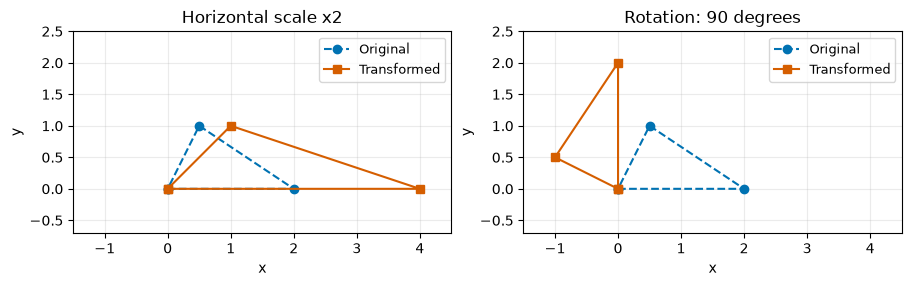

In [14]:
import matplotlib.pyplot as plt

# 每列是一个二维点；末列重复首点，让折线闭合成三角形。
points = np.array([[0.0, 2.0, 0.5, 0.0], [0.0, 0.0, 1.0, 0.0]])
fig, axes = plt.subplots(1, 2, figsize=(9, 4), layout="constrained")

for ax, matrix, title in zip(
    axes, [stretch, rotation], ["Horizontal scale x2", "Rotation: 90 degrees"]
):
    # (2, 2) @ (2, 4) 同时变换四列坐标，结果仍按列存点。
    transformed = matrix @ points
    ax.plot(points[0], points[1], "o--", color="#0072B2", label="Original")
    ax.plot(
        transformed[0],
        transformed[1],
        "s-",
        color="#D55E00",
        label="Transformed",
    )
    ax.set(xlabel="x", ylabel="y", title=title, xlim=(-1.5, 4.5), ylim=(-0.7, 2.5))
    # 两个坐标轴使用相同单位长度，避免图形比例掩盖变换效果。
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)

# 左图宽度扩大，右图向逆时针转动；两图中原点都保持不动。
plt.show()

## 6 复合顺序与综合应用

### 6.1 先做的变换写在右侧

设 $B:\mathbb{R}^p\to\mathbb{R}^n$、$A:\mathbb{R}^n\to\mathbb{R}^m$ 分别由同名字母的矩阵表示，输入 $x\in\mathbb{R}^p$。先 B 后 A 得到 $A(Bx)=(AB)x$。结合律允许改变括号，不允许随意交换矩阵。

沿用上一节的 S（stretch）与 R（rotation），先缩放后旋转得到

$$RS=\begin{bmatrix}0&-1\\2&0\end{bmatrix},\qquad RS\begin{bmatrix}2\\1\end{bmatrix}=\begin{bmatrix}-1\\4\end{bmatrix}.$$

交换顺序则得到 $SR=\begin{bmatrix}0&-2\\1&0\end{bmatrix}$，同一点变成 $\begin{bmatrix}-2\\2\end{bmatrix}$。两个结果不同，说明矩阵乘法通常不满足交换律。

In [15]:
scale_then_rotate = rotation @ stretch
rotate_then_scale = stretch @ rotation

print(scale_then_rotate @ point)  # 预期：[-1.  4.]。
print(rotate_then_scale @ point)  # 预期：[-2.  2.]。
print(rotation @ (stretch @ point))  # 同样为 [-1.  4.]，核对结合律。

[-1.  4.]
[-2.  2.]
[-1.  4.]


### 6.2 复合与恢复三角形

继续使用上一节的 points，比较两种顺序。如果两个变换都可逆，撤销时也要反过来：先撤销旋转，再撤销缩放。对本例有

$$(RS)^{-1}=S^{-1}R^{-1},\qquad
(S^{-1}R^{-1})(RS)=S^{-1}(R^{-1}R)S=S^{-1}S=I_2.$$

下面打印恢复后与原坐标的最大绝对差，再绘制两种复合结果。图形帮助观察，矩阵定义与运算规则才是解释顺序的依据。

(2, 4)
0.0


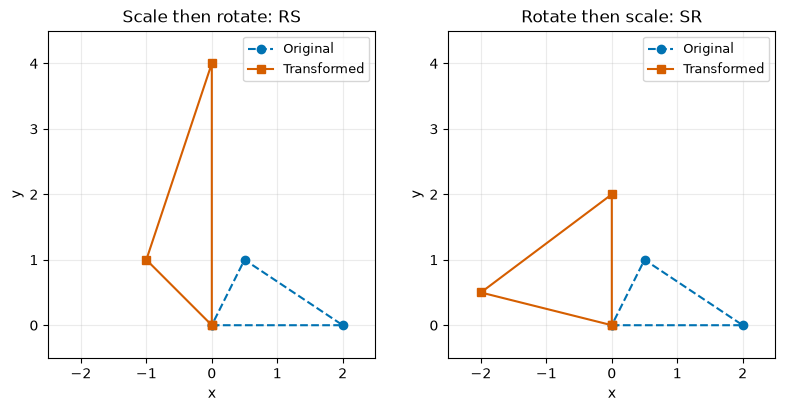

In [16]:
# 先生成复合变换结果，再按相反顺序施加两个逆变换。
combined_points = scale_then_rotate @ points
restored = np.linalg.inv(stretch) @ np.linalg.inv(rotation) @ combined_points
print(restored.shape)  # 预期：(2, 4)，仍按列保存点。
print(np.max(np.abs(restored - points)))  # 本例预期：0.0。

# 左右图只改变矩阵相乘的顺序，使用相同原图和坐标范围比较。
fig, axes = plt.subplots(1, 2, figsize=(8, 4), layout="constrained")
for ax, matrix, title in zip(
    axes,
    [scale_then_rotate, rotate_then_scale],
    ["Scale then rotate: RS", "Rotate then scale: SR"],
):
    transformed = matrix @ points
    ax.plot(points[0], points[1], "o--", color="#0072B2", label="Original")
    ax.plot(
        transformed[0],
        transformed[1],
        "s-",
        color="#D55E00",
        label="Transformed",
    )
    ax.set(xlabel="x", ylabel="y", title=title, xlim=(-2.5, 2.5), ylim=(-0.5, 4.5))
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)

# 左图顶部达到 y=4，右图顶部为 y=2；两种复合不是同一变换。
plt.show()

## 本章小结

（1）数学向量的分量数、数组轴数、矩阵的行列数描述不同信息，计算前先明确布局与 shape。

（2）矩阵乘向量是各列的线性组合；矩阵乘矩阵要先匹配内侧维度。* 与 @ 表示不同运算。

（3）转置交换行列；单位矩阵保持输入；可逆矩阵的逆才能撤销其变换。压掉坐标的变换可能丢失信息。

（4）线性变换保持加法与数乘，必定保持原点；复合时先做的变换位于右侧。可逆复合的撤销顺序也要反转。

理解自查：为什么 point.T 不是列向量？为什么先缩放再旋转一般不等于先旋转再缩放？能否只用原点不动就断言线性？

## 练习

（1）手算并检查形状

给定下面形状为 (2, 3) 和 (3, 2) 的两个矩阵，先手算 left_ex @ right_ex，再用代码核对每个元素。写出反向乘法的结果形状，并说明为什么不能用 * 代替本题的 @。

可验证标准：前向结果的形状为 (2, 2)，四个元素都与行乘列的手算一致；解释应包含对应的维度条件。

In [17]:
left_ex = np.array([[1, 0, 2], [0, -1, 1]])
right_ex = np.array([[2, 1], [3, 0], [1, 4]])
# 在这里计算并打印结果，再逐项核对手算。

（2）预测形状并修正布局

下面的一维数组 values 与列数组 values_column 保存相同分量。先预测 values + values_column 的形状，再把两个输入都整理为列向量后相加。

可验证标准：能解释广播为何产生额外列；修正后的形状为 (3, 1)，三个分量都是原值的两倍。

In [18]:
values = np.array([1.0, 2.0, 3.0])
values_column = values.reshape(3, 1)
# 在这里记录预测，运行后打印 shape，再修正布局。

（3）改变缩放条件

把横向缩放系数改成 0，纵向保持不变，再复合逆时针 $90^\circ$ 旋转。先判断能否用逆恢复原输入，并构造两个不同输入使复合后的输出相同。

可验证标准：打印两个输入和两个输出；用丢失的信息解释不可逆，而不只展示 inv 报错。

In [19]:
zero_scale = np.array([[0.0, 0.0], [0.0, 1.0]])
quarter_turn = np.array([[0.0, -1.0], [1.0, 0.0]])
# 在这里构造输入并计算；先明确本题是先缩放后旋转。

（4）保持原点是否足够

考虑 $G:\mathbb{R}^2\to\mathbb{R}^2$，$G(x)=\begin{bmatrix}x_1^2\\x_2\end{bmatrix}$，其中 $x_1,x_2$ 是输入的两个坐标。G 保持原点。判断它是否线性，并选择一个非零输入检查数乘条件。

可验证标准：给出同一个输入 u 下 G(2u) 与 2G(u) 的结果，用定义解释结论；一组反例足以否定“对所有输入成立”。

In [20]:
def curved_transform(vector):
    """把第一个坐标平方，保留第二个坐标。"""
    return np.array([vector[0] ** 2, vector[1]])


# 在这里选择输入，比较数乘前后的结果。

## 练习提示与解析

以下对应练习（4）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：线性要求数乘条件对所有输入成立；保持原点只是一项必要条件。

提示 2：选择第一坐标非零、第二坐标为零的输入，比较先加倍与后加倍。

### 练习（4）参考解析

取 $u=(1,0)^T$，有 $G(u)=(1,0)^T$，但 $G(2u)=(4,0)^T$，而 $2G(u)=(2,0)^T$。两者不同，数乘条件失效，因此 G 不是线性变换。

若只取第一坐标为零的向量，这次比较可能相同，却不能证明条件对所有输入成立。反例可以否定全称命题；几个成功样本不能证明它。

## 参考与引用来源

以下页面于 2026-09-21 核查。数值与图形示例为本章编写，数学结论与 API 行为分别按下表定位。

| 网站 | 本章参考内容与定位 |
| --- | --- |
| Deep Learning 作者网站 | [第 2 章](https://www.deeplearningbook.org/contents/linear_algebra.html)：§2.1 的标量、向量、矩阵、转置；§2.2 的逐元素乘法与矩阵乘法、式 (2.9) 的乘积转置；§2.3 的单位矩阵。 |
| Georgia Tech：Interactive Linear Algebra | [§2.1 Vectors](https://textbooks.math.gatech.edu/ila/vectors.html)：§2.1.2–2.1.3 的数乘、加法与线性组合；[§2.3 Matrix Equations](https://textbooks.math.gatech.edu/ila/matrix-equations.html)：§2.3.1 的按列与按行计算；[§3.1 Matrix Transformations](https://textbooks.math.gatech.edu/ila/matrix-transformations.html)：§3.1.1 的缩放与旋转例子；[§3.3 Linear Transformations](https://textbooks.math.gatech.edu/ila/linear-transformations.html)：§3.3.1 的定义、原点与平移，§3.3.2–3.3.3 的标准坐标向量与矩阵列；[§3.4 Matrix Multiplication](https://textbooks.math.gatech.edu/ila/matrix-multiplication.html)：§3.4.1–3.4.3 的维度、乘法与复合；[§3.5 Matrix Inverses](https://textbooks.math.gatech.edu/ila/matrix-inverses.html)：§3.5.1 的双侧逆与乘积逆，§3.5.4 的可逆变换。 |
| NumPy 2.5 官方文档 | [Quickstart](https://numpy.org/doc/stable/user/quickstart.html)：The basics、Array creation、Basic operations、Changing the shape；[matmul](https://numpy.org/doc/stable/reference/generated/numpy.matmul.html)：Notes 的二维与一维规则；[transpose](https://numpy.org/doc/stable/reference/generated/numpy.transpose.html)：一维与二维区别；[Broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html)：General broadcasting rules；[linalg.inv](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html)：双侧乘积、Raises 与 Notes 的数值边界；[allclose](https://numpy.org/doc/stable/reference/generated/numpy.allclose.html)：容差条件；[eye](https://numpy.org/doc/stable/reference/generated/numpy.eye.html)：单位矩阵的创建。 |
| Matplotlib 3.11 官方文档 | [subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html)：一行多图；[Axes.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html)：坐标、线型与标记；[Axes.set_aspect](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_aspect.html)：equal 的同尺度含义；[show](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html)：显示图形。 |